# High Fidelity Neural Network
Neural Network which uses HF dataset and exploits the High fidelity component of the MF model  

In [33]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import (
    getModel,
    kCrossVal,
    transfBestparam,
    kCrossValSingle,
    import_data, normalization
)
from time import perf_counter
import pandas
import os
from itertools import product
import keras
import tensorflow as tf


In [34]:
# reproducibility
seed=42
np.random.seed(seed)

keras.utils.set_random_seed(seed)

tf.random.set_seed(seed)

# Data preparation

In [35]:
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, t_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[:, :,44,44]
t_HF_test=t_HF_test.T


In [36]:
reaction_HF_test = normalization(reaction_HF_test)
t_HF_test = normalization(t_HF_test)
U_HF_test = normalization(U_HF_test)

In [37]:
NepoHF = 1000  # number of epochs for second NN: NN_HF
Nhf = 100

In [38]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(t_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:Nhf]
t_HF = t_HF_test[permutation2][0:Nhf]

grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), t_HF_test.flatten())))

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]

##
p1, p2 = np.meshgrid(permutation1[0:Nhf], permutation2[0:Nhf])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##


# Neural Network

In [39]:
start = perf_counter()

name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()

best_params = {
    "kernel_init": "uniform",
    "l2weight": 0.0002588943618918075,
    "lr": 0.005,
    "nodes": 64.0,
    "opt": "Adam",
}

print(best_params)
        
# reaction_final = np.vstack(
#     (reaction_HF)
# ) 

# MAX_EVAL = 1
# name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
# K.clear_session()
# bayes_trials = Trials()
# opt_list = ["Adam", "Adamax"]
# kernel_list = ["uniform", "glorot_uniform"]
# aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
# space = {
#     "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
#     "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
#     "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
#     "kernel_init": hp.choice("kernel_init", kernel_list),
#     "opt": hp.choice("opt", opt_list),
# }


# def objective(params):
#     K.clear_session()
#     #CVres = kCrossValSingle(Nhf, NepoHF, reaction_final, U_HF, params, name)
#     CVres = kCrossVal(2,Nhf, NepoHF, reaction_final, U_HF, params, name)

#     return {"loss": CVres, "params": params, "status": STATUS_OK}


# best_params = fmin(
#     fn=objective,
#     space=space,
#     algo=tpe.suggest,
#     max_evals=MAX_EVAL,
#     trials=bayes_trials,
# )

# transfBestparam(best_params, aux_dic)
# print(best_params)


{'kernel_init': 'uniform', 'l2weight': 0.0002588943618918075, 'lr': 0.005, 'nodes': 64.0, 'opt': 'Adam'}


In [40]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()

finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_HF,
    U_HF,
    validation_data=(reaction_HF_test, U_HF_test),
    epochs=NepoHF,
    batch_size=Nhf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_HF_test)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nHF Model:")
test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

1252/1252 [==============================] - 2s 1ms/step
Elapsed time:  164.2071531000547

HF Model:
Elapsed time:  163.98024920001626

HF Model:
Test MSE: 0.11283055660587757
R^2: -0.0016614303848019318


# Post processing

1252/1252 [==============================] - 2s 2ms/step


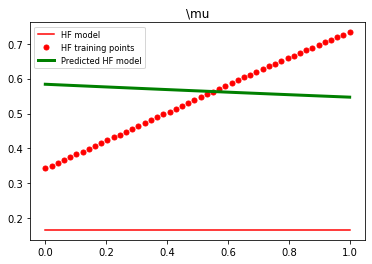

1252/1252 [==============================] - 2s 1ms/step


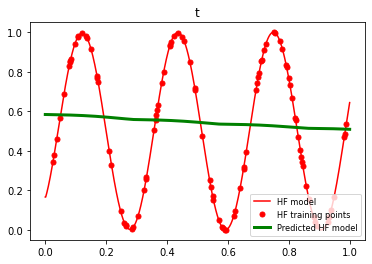

In [41]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
mask1_test=np.where(reaction_HF_test[:,1]==np.min(reaction_HF_test[:,1]))
mask1=np.where(reaction_HF[:,1]==np.min(reaction_HF[:,1]))

# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_HF_test[mask1_test,0].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
plt.plot(reaction_HF[mask1,0].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test[mask1_test,0].T,
    finalModel.predict(reaction_HF_test)[mask1_test],
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.title("\mu")
plt.show()

mask2_test=np.where(reaction_HF_test[:,0]==np.min(reaction_HF_test[:,0]))
mask2=np.where(reaction_HF[:,0]==np.min(reaction_HF[:,0]))
plt.figure()
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_HF_test[mask2_test,1].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
plt.plot(reaction_HF[mask2,1].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test[mask2_test,1].T,
    finalModel.predict(reaction_HF_test)[mask2_test],
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.title("t")
plt.show()

In [42]:
########################     SAVE the OUTPUT      ##########################

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! change the name of the new folder !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
os.makedirs("NNHF_HF_100_1000steps")

R2_HF = pandas.DataFrame({"R2_HF": [r2_HF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [test_mse]})


# R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv(
    "./NNHF_HF_100_1000steps/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNHF_HF_100_1000steps/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)